# Solution for the first science case

In this section, we are visualizing astronomical data from an aperture-based observation, comparing observed and absolute magnitudes of stars. We will plot two graphs side by side, showing the g-i vs. g and the corresponding absolute magnitude corrected for distance modulus.

In [1]:
# needed Python imports
# imports for data retrieve
import splusdata
import numpy as np
from matplotlib import pyplot as plt

## S-PLUS Catalogs choice

In [4]:
conn = splusdata.Core()

In [22]:
tab = conn.query(""" 
select top 10000 i.*, sq.plx, sq.e_plx, sq.pmra, sq.e_pmra, sq.pmde, sq.e_pmde from idr6.idr6 as i join
idr6.vac_sqg as sq on i.id = sq.id
where 
i.class_star_r > 0.8
"""
# and cone(i.ra, i.dec, 323.36249, -0.82333, 0.5)
)

In [23]:
objects_table = tab

## Perform the crossmatch

<hr>

## Create plots

###  Selection of objects

In [25]:
import numpy as np

# ============================================================
# Configuration
# ============================================================

aperture = "psf"


# ============================================================
# Convert relevant columns to NumPy arrays
# ============================================================

parallax = np.asarray(objects_table["plx"], dtype=float)
parallax_error = np.asarray(objects_table["e_plx"], dtype=float)

snr_g = np.asarray(
    objects_table[f"s2n_{aperture}_g"],
    dtype=float
)

snr_i = np.asarray(
    objects_table[f"s2n_{aperture}_i"],
    dtype=float
)

mag_r = np.asarray(
    objects_table[f"mag_{aperture}_r"],
    dtype=float
)


# ============================================================
# Gaia parallax validation
# ============================================================

valid_parallax = (
    np.isfinite(parallax)
    & np.isfinite(parallax_error)
    & (parallax > 0)
    & (parallax_error > 0)
)


# ============================================================
# Distance from Gaia parallax
# ============================================================

distance_pc = np.full(len(objects_table), np.nan, dtype=float)

distance_pc[valid_parallax] = (
    1000.0 / parallax[valid_parallax]
)


# Absolute-magnitude correction:
# M = m - 5 log10(d) + 5
mabs_corr = np.full(len(objects_table), np.nan, dtype=float)

mabs_corr[valid_parallax] = (
    -5 * np.log10(distance_pc[valid_parallax]) + 5
)


# ============================================================
# Gaia parallax quality
# ============================================================

# Require parallax signal-to-noise greater than 5
parallax_snr = np.full(len(objects_table), np.nan)

parallax_snr[valid_parallax] = (
    parallax[valid_parallax]
    / parallax_error[valid_parallax]
)

parallax_mask = (
    valid_parallax
    & (parallax_snr > 5)
)


# ============================================================
# S-PLUS photometric quality
# ============================================================

QC_mask = (
    np.isfinite(snr_g)
    & np.isfinite(snr_i)
    & np.isfinite(mag_r)
    & (snr_g > 30)
    & (snr_g < 1000)
    & (snr_i > 30)
    & (snr_i < 1000)
    & (mag_r > 14)
    & (mag_r < 19)
)


# ============================================================
# Final sample
# ============================================================

mask = parallax_mask & QC_mask

print(f"Total objects: {len(objects_table)}")
print(f"Selected field stars: {mask.sum()}")

Total objects: 10000
Selected field stars: 3165


## RA and DEC distribution

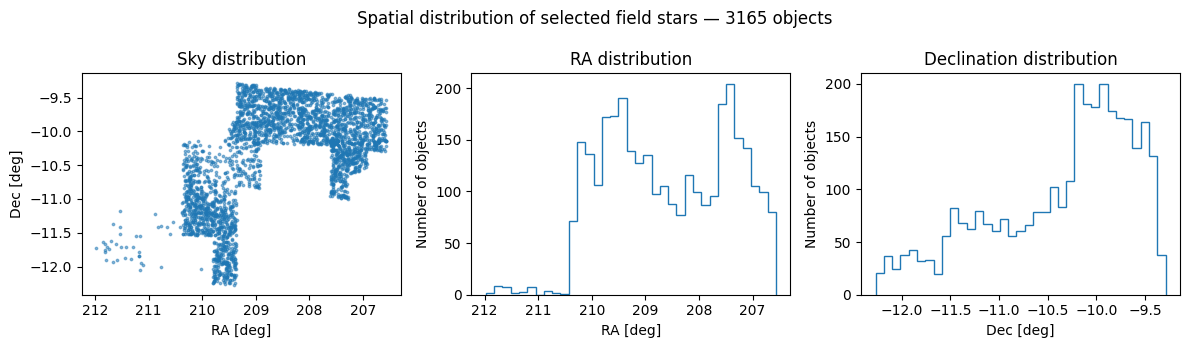

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Coordinates
# ============================================================

ra = np.asarray(objects_table["ra"], dtype=float)
dec = np.asarray(objects_table["dec"], dtype=float)

spatial_mask = (
    mask
    & np.isfinite(ra)
    & np.isfinite(dec)
)

N = spatial_mask.sum()

# ============================================================
# Spatial plots
# ============================================================

fig, (ax1, ax2, ax3) = plt.subplots(
    1,
    3,
    figsize=(12, 3.5)
)

fig.suptitle(
    f"Spatial distribution of selected field stars — {N} objects"
)

# Sky distribution
ax1.scatter(
    ra[spatial_mask],
    dec[spatial_mask],
    s=3,
    alpha=0.5
)

ax1.set_xlabel("RA [deg]")
ax1.set_ylabel("Dec [deg]")
ax1.set_title("Sky distribution")

# Astronomical convention
ax1.invert_xaxis()

# RA distribution
ax2.hist(
    ra[spatial_mask],
    bins=35,
    histtype="step"
)

ax2.set_xlabel("RA [deg]")
ax2.set_ylabel("Number of objects")
ax2.set_title("RA distribution")
ax2.invert_xaxis()

# Declination distribution
ax3.hist(
    dec[spatial_mask],
    bins=35,
    histtype="step"
)

ax3.set_xlabel("Dec [deg]")
ax3.set_ylabel("Number of objects")
ax3.set_title("Declination distribution")

plt.tight_layout()
plt.show()

## H.R. Diagrams 

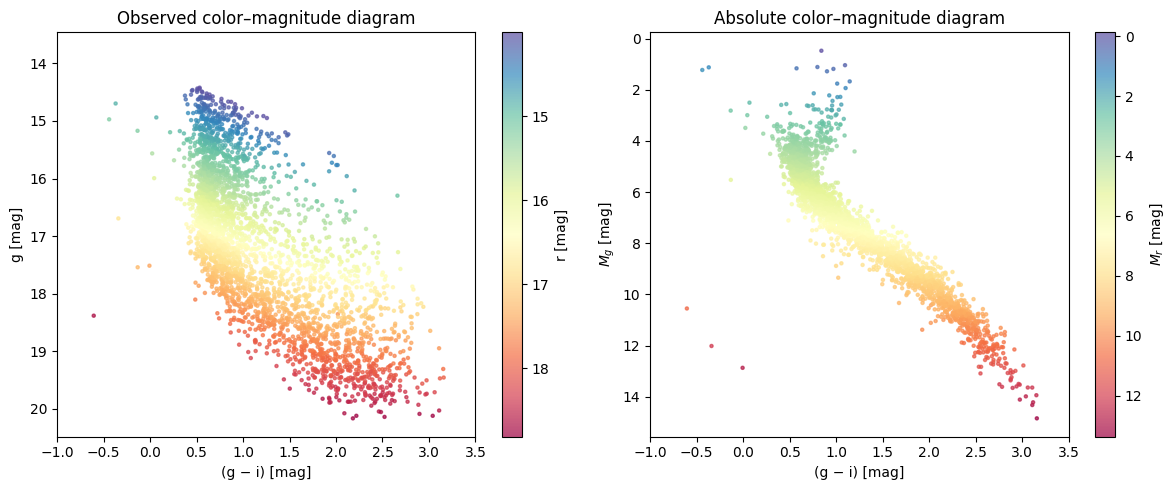

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Photometry
# ============================================================

g_mag = np.asarray(
    objects_table[f"mag_{aperture}_g"],
    dtype=float
)

i_mag = np.asarray(
    objects_table[f"mag_{aperture}_i"],
    dtype=float
)

r_mag = np.asarray(
    objects_table[f"mag_{aperture}_r"],
    dtype=float
)

g_minus_i = g_mag - i_mag

# Absolute magnitudes calculated using Gaia distances
absolute_g = g_mag + mabs_corr
absolute_r = r_mag + mabs_corr

# ============================================================
# Plot mask
# ============================================================

plot_mask = (
    mask
    & np.isfinite(g_mag)
    & np.isfinite(i_mag)
    & np.isfinite(r_mag)
    & np.isfinite(g_minus_i)
    & np.isfinite(absolute_g)
    & np.isfinite(absolute_r)
)

# ============================================================
# Create plots
# ============================================================

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

# Observed CMD
sc1 = ax1.scatter(
    g_minus_i[plot_mask],
    g_mag[plot_mask],
    c=r_mag[plot_mask],
    s=5,
    alpha=0.7,
    cmap="Spectral_r"
)

ax1.set_title("Observed color–magnitude diagram")
ax1.set_xlabel("(g − i) [mag]")
ax1.set_ylabel("g [mag]")
ax1.set_xlim(-1, 3.5)
ax1.invert_yaxis()

cbar1 = fig.colorbar(sc1, ax=ax1)
cbar1.set_label("r [mag]")
cbar1.ax.invert_yaxis()

# Absolute CMD
sc2 = ax2.scatter(
    g_minus_i[plot_mask],
    absolute_g[plot_mask],
    c=absolute_r[plot_mask],
    s=5,
    alpha=0.7,
    cmap="Spectral_r"
)

ax2.set_title("Absolute color–magnitude diagram")
ax2.set_xlabel("(g − i) [mag]")
ax2.set_ylabel(r"$M_g$ [mag]")
ax2.set_xlim(-1, 3.5)
ax2.invert_yaxis()

cbar2 = fig.colorbar(sc2, ax=ax2)
cbar2.set_label(r"$M_r$ [mag]")
cbar2.ax.invert_yaxis()

plt.tight_layout()
plt.show()

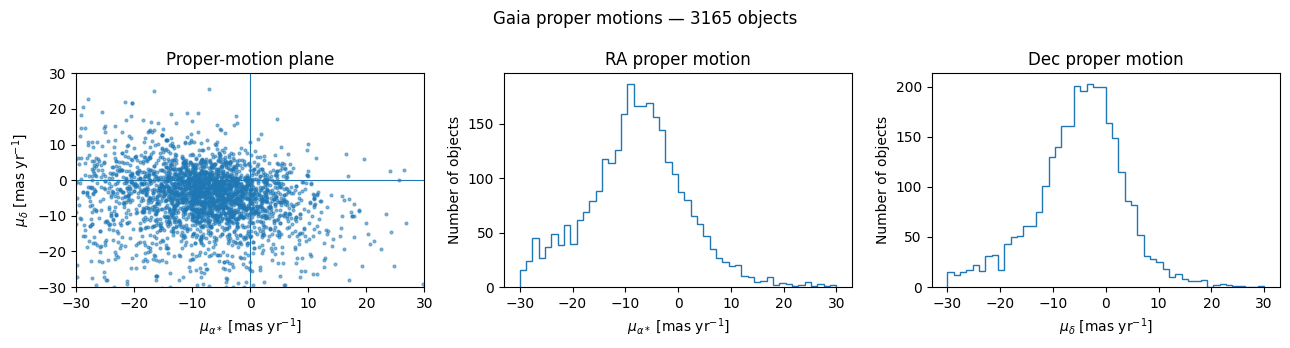

In [28]:
import matplotlib.pyplot as plt
import numpy as np

pmra = np.asarray(objects_table["pmra"], dtype=float)
pmdec = np.asarray(objects_table["pmde"], dtype=float)

pm_mask = (
    mask
    & np.isfinite(pmra)
    & np.isfinite(pmdec)
)

fig, (ax1, ax2, ax3) = plt.subplots(
    1,
    3,
    figsize=(13, 3.5)
)

fig.suptitle(
    f"Gaia proper motions — {pm_mask.sum()} objects"
)

# Proper-motion plane
ax1.scatter(
    pmra[pm_mask],
    pmdec[pm_mask],
    s=4,
    alpha=0.5
)

ax1.axhline(0, linewidth=0.8)
ax1.axvline(0, linewidth=0.8)

ax1.set_xlabel(r"$\mu_{\alpha*}$ [mas yr$^{-1}$]")
ax1.set_ylabel(r"$\mu_{\delta}$ [mas yr$^{-1}$]")
ax1.set_title("Proper-motion plane")

# Restrict the visualization to avoid extreme outliers
ax1.set_xlim(-30, 30)
ax1.set_ylim(-30, 30)

# PMRA histogram
ax2.hist(
    pmra[pm_mask],
    bins=50,
    range=(-30, 30),
    histtype="step"
)

ax2.set_xlabel(r"$\mu_{\alpha*}$ [mas yr$^{-1}$]")
ax2.set_ylabel("Number of objects")
ax2.set_title("RA proper motion")

# PMDEC histogram
ax3.hist(
    pmdec[pm_mask],
    bins=50,
    range=(-30, 30),
    histtype="step"
)

ax3.set_xlabel(r"$\mu_{\delta}$ [mas yr$^{-1}$]")
ax3.set_ylabel("Number of objects")
ax3.set_title("Dec proper motion")

plt.tight_layout()
plt.show()

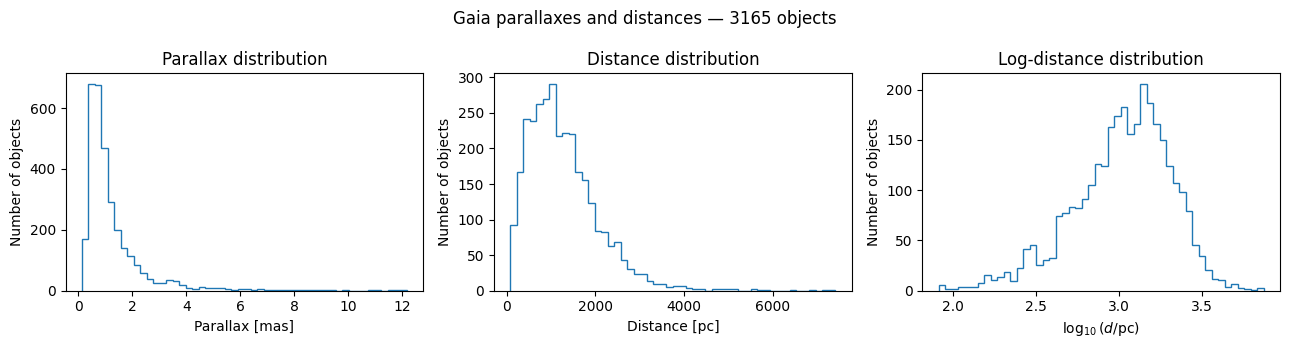

In [29]:
import matplotlib.pyplot as plt
import numpy as np

distance_mask = (
    mask
    & np.isfinite(parallax)
    & np.isfinite(parallax_error)
    & np.isfinite(distance_pc)
    & (parallax > 0)
    & (distance_pc > 0)
)

fig, (ax1, ax2, ax3) = plt.subplots(
    1,
    3,
    figsize=(13, 3.5)
)

fig.suptitle(
    f"Gaia parallaxes and distances — {distance_mask.sum()} objects"
)

# Parallax distribution
ax1.hist(
    parallax[distance_mask],
    bins=50,
    histtype="step"
)

ax1.set_xlabel("Parallax [mas]")
ax1.set_ylabel("Number of objects")
ax1.set_title("Parallax distribution")

# Distance distribution
ax2.hist(
    distance_pc[distance_mask],
    bins=50,
    histtype="step"
)

ax2.set_xlabel("Distance [pc]")
ax2.set_ylabel("Number of objects")
ax2.set_title("Distance distribution")

# Logarithmic distance distribution
ax3.hist(
    np.log10(distance_pc[distance_mask]),
    bins=50,
    histtype="step"
)

ax3.set_xlabel(r"$\log_{10}(d/\mathrm{pc})$")
ax3.set_ylabel("Number of objects")
ax3.set_title("Log-distance distribution")

plt.tight_layout()
plt.show()